In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training" , output_dir = "datasets/cafe-sales-dirty-data-for-cleaning-training")

print("Path to dataset files:", path)

100%|██████████| 111k/111k [00:00<00:00, 228kB/s]

Extracting files...
Path to dataset files: datasets/cafe-sales-dirty-data-for-cleaning-training


In [53]:
df = pd.read_csv(f'datasets/cafe-sales-dirty-data-for-cleaning-training/dirty_cafe_sales.csv')

print(f"Shape: {df.shape}")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape: (10000, 8)
Rows: 10000
Columns: 8


In [6]:
print(df.columns.tolist())

['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [8]:
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


We expect Quantity, Price Per Unit and Total Spent to have numeric data types.

In [9]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


Transaction ID:
Transaction ID
TXN_1961373    1
TXN_4977031    1
TXN_4271903    1
TXN_7034554    1
TXN_3160411    1
              ..
TXN_7672686    1
TXN_9659401    1
TXN_5255387    1
TXN_7695629    1
TXN_6170729    1
Name: count, Length: 10000, dtype: int64

Item:
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64

Quantity:
Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
NaN         138
Name: count, dtype: int64

Price Per Unit:
Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
NaN         179
UNKNOWN     164
Name: count, dtype: int64

Total Spent:
Total Spent
6.0        979
12.0       939
3.0        930
4.0        923
20.0       746
15.0       734
8.0        677
10.0    

We can see that in numeric columns, there are float, NaN, and UNKNOWN, ERROR string.

In [10]:
null_counts = df.isnull().sum()
print(null_counts)

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


In [11]:
null_percentage = null_counts / len(df) * 100
print(null_percentage)

Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64


In [12]:
null_df = pd.DataFrame({
    'null_count': null_counts,
    'null_pct': null_percentage
}).sort_values('null_pct', ascending=False)
null_df

,null_count,null_pct
Location,3265,32.65
Payment Method,2579,25.79
Item,333,3.33
Price Per Unit,179,1.79
Total Spent,173,1.73
Transaction Date,159,1.59
Quantity,138,1.38
Transaction ID,0,0.00


Unique value count

In [15]:
for col in df.columns:
    print(f"{col}: {df[col].nunique(dropna=False)}")

Transaction ID: 10000
Item: 11
Quantity: 8
Price Per Unit: 9
Total Spent: 20
Payment Method: 6
Location: 5
Transaction Date: 368


In [ ]:
for col in df.columns:
    print(f"\n{'='*40}")
    print(f"Column: {col}")

    # Normal values (not NaN, not UNKNOWN/ERROR)
    normal = df[col][~df[col].isin(['UNKNOWN', 'ERROR']) & df[col].notna()].unique()

    # NaN
    nan_count = df[col].isna().sum()

    # Others (UNKNOWN, ERROR)
    others = df[col][df[col].isin(['UNKNOWN', 'ERROR'])].unique()

    print(f"Normal  ({len(normal)}): {normal[:10]}")
    print(f"NaN     ({nan_count} rows)")
    print(f"Others  ({len(others)}): {others}")


Column: Transaction ID
Normal  (10000): <StringArray>
['TXN_1961373', 'TXN_4977031', 'TXN_4271903', 'TXN_7034554', 'TXN_3160411',
 'TXN_2602893', 'TXN_4433211', 'TXN_6699534', 'TXN_4717867', 'TXN_2064365']
Length: 10, dtype: str
NaN     (0 rows)
Others  (0): <StringArray>
[]
Length: 0, dtype: str

Column: Item
Normal  (8): <StringArray>
['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Sandwich', 'Juice', 'Tea']
Length: 8, dtype: str
NaN     (333 rows)
Others  (2): <StringArray>
['UNKNOWN', 'ERROR']
Length: 2, dtype: str

Column: Quantity
Normal  (5): <StringArray>
['2', '4', '5', '3', '1']
Length: 5, dtype: str
NaN     (138 rows)
Others  (2): <StringArray>
['ERROR', 'UNKNOWN']
Length: 2, dtype: str

Column: Price Per Unit
Normal  (6): <StringArray>
['2.0', '3.0', '1.0', '5.0', '4.0', '1.5']
Length: 6, dtype: str
NaN     (179 rows)
Others  (2): <StringArray>
['ERROR', 'UNKNOWN']
Length: 2, dtype: str

Column: Total Spent
Normal  (17): <StringArray>
['4.0', '12.0', '10.0', '20.0', '9.

basic statistics

In [22]:
# Numeric columns - convert temporarily to see stats
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    temp = pd.to_numeric(df[col], errors='coerce')
    print(f"\n--- {col} ---")
    print(f"mean   : {temp.mean():.2f}")
    print(f"median : {temp.median():.2f}")
    print(f"min    : {temp.min():.2f}")
    print(f"max    : {temp.max():.2f}")
    print(f"std    : {temp.std():.2f}")


--- Quantity ---
mean   : 3.03
median : 3.00
min    : 1.00
max    : 5.00
std    : 1.42

--- Price Per Unit ---
mean   : 2.95
median : 3.00
min    : 1.00
max    : 5.00
std    : 1.28

--- Total Spent ---
mean   : 8.92
median : 8.00
min    : 1.00
max    : 25.00
std    : 6.01


Distributions of numeric columns

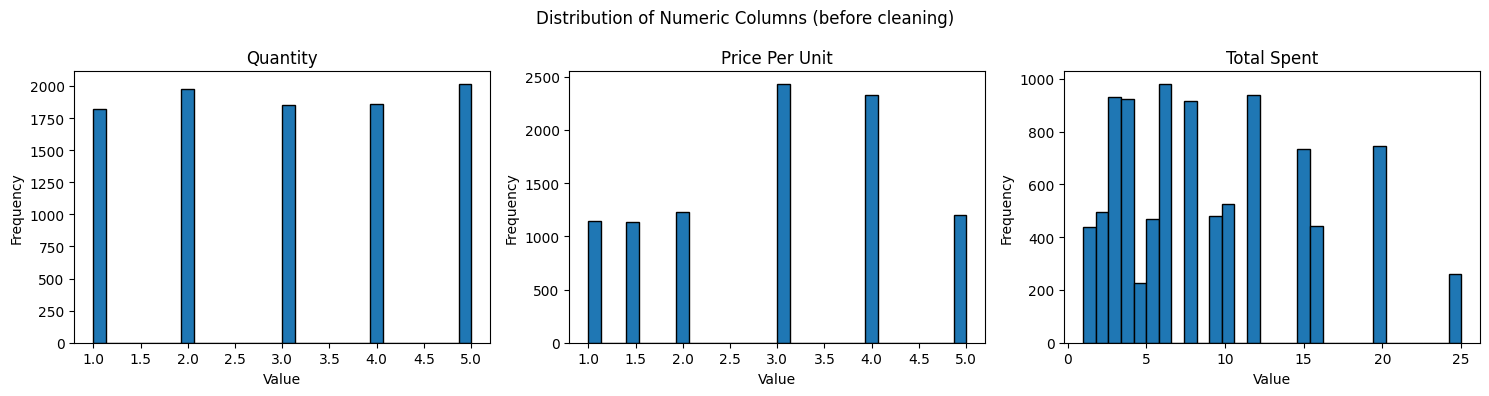

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cols = ['Quantity', 'Price Per Unit', 'Total Spent']

for i, col in enumerate(cols):
    temp = pd.to_numeric(df[col], errors='coerce')
    axes[i].hist(temp.dropna(), bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Numeric Columns (before cleaning)')
plt.tight_layout()
plt.show()

Value counts for Categorical Columns

In [24]:
# Date range
print(f"\n--- Transaction Date ---")
temp_date = pd.to_datetime(df['Transaction Date'], errors='coerce')
print(f"earliest : {temp_date.min()}")
print(f"latest   : {temp_date.max()}")

# Categorical columns
for col in ['Item', 'Payment Method', 'Location']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Transaction Date ---
earliest : 2023-01-01 00:00:00
latest   : 2023-12-31 00:00:00

--- Item ---
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64

--- Payment Method ---
Payment Method
NaN               2579
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

--- Location ---
Location
NaN         3265
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64


Step 2: Define Quality Rules
Transaction ID: must be unique, string Item: No UNKNOWN/ERROR Quantity: Must be positive integer, No UNKNOWN/ERROR, no null Price Per Unit: Must be positive float, no UNKNOWN/ERROR, no null Total Spent: Must equal Quantity * Price Per Unit, No UNKNOWN/ERROR

Payment method: No UNKNOWN/ERROR, nullable, flag

Location: No UNKNOWN/ERROR, nullable, flag

Transaction Date: Format YYYY-MM-DD, within reasonable range, no UNKNOWN/ERROR, no null

# Step 3: Handle missing values

In [54]:
#Replace all UNKNOWN/ERROR to NaN
import numpy as np

df_clean = df.copy()
df_clean.replace(['UNKNOWN', 'ERROR'], np.nan, inplace=True)

# Verify
print("Null counts BEFORE:")
print(df.isnull().sum())

print("\nNull counts AFTER:")
print(df_clean.isnull().sum())

Null counts BEFORE:
Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

Null counts AFTER:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


missingno to discover missing value patterns 

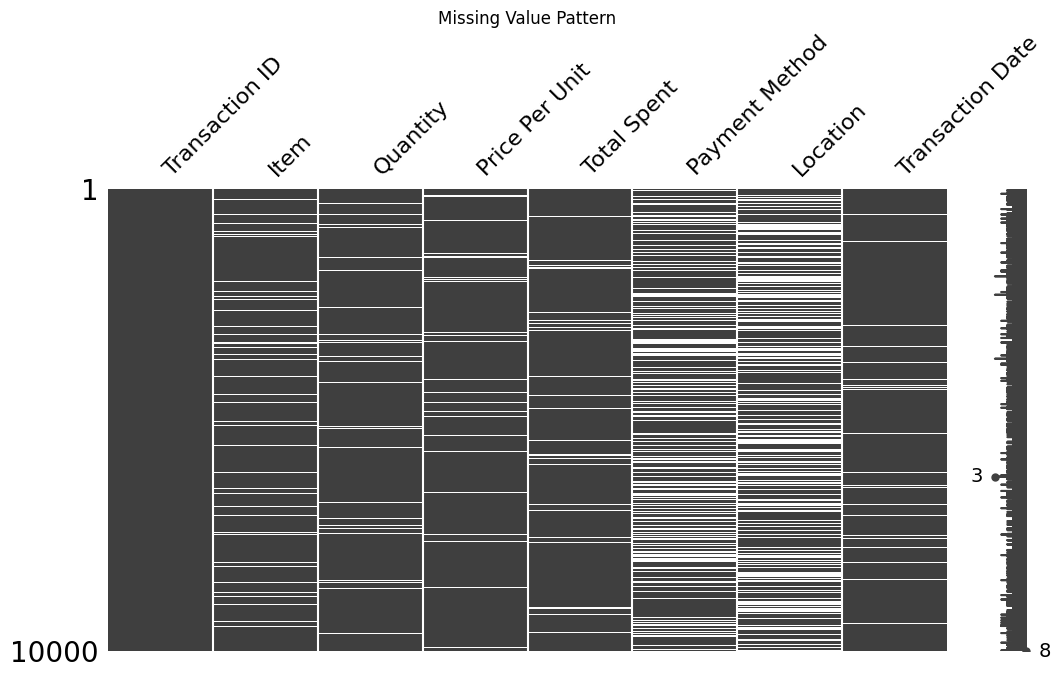

In [4]:
#Analyze missing pattern
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df_clean, figsize=(12, 6))
plt.title('Missing Value Pattern')
plt.show()

In [5]:
df_clean

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [6]:
# Test all columns for MCAR vs MAR
cols_to_test = ['Item', 'Quantity', 'Price Per Unit', 'Total Spent',
                'Payment Method', 'Location', 'Transaction Date']

numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']

for test_col in cols_to_test:
    print(f"\n{'='*50}")
    print(f"Testing: is '{test_col}' missing MCAR or MAR?")
    print(f"{'='*50}")

    # Create binary flag: 1 = missing, 0 = not missing
    missing_flag = df_clean[test_col].isnull().astype(int)

    # Skip if no missing values
    if missing_flag.sum() == 0:
        print("No missing values — skip ✅")
        continue

    print(f"Missing rows: {missing_flag.sum()}")

    # Compare means of numeric columns between missing vs not missing
    for num_col in numeric_cols:
        if num_col == test_col:
            continue
        temp = pd.to_numeric(df_clean[num_col], errors='coerce')
        mean_missing     = temp[missing_flag == 1].mean()
        mean_not_missing = temp[missing_flag == 0].mean()
        diff = abs(mean_missing - mean_not_missing)
        flag = '⚠️ MAR' if diff > 0.5 else '✅ MCAR'
        print(f"  {num_col}: missing={mean_missing:.2f} | not_missing={mean_not_missing:.2f} | diff={diff:.2f} {flag}")


Testing: is 'Item' missing MCAR or MAR?
Missing rows: 969
  Quantity: missing=3.02 | not_missing=3.03 | diff=0.01 ✅ MCAR
  Price Per Unit: missing=2.93 | not_missing=2.95 | diff=0.02 ✅ MCAR
  Total Spent: missing=8.86 | not_missing=8.93 | diff=0.07 ✅ MCAR

Testing: is 'Quantity' missing MCAR or MAR?
Missing rows: 479
  Price Per Unit: missing=2.91 | not_missing=2.95 | diff=0.04 ✅ MCAR
  Total Spent: missing=8.68 | not_missing=8.94 | diff=0.26 ✅ MCAR

Testing: is 'Price Per Unit' missing MCAR or MAR?
Missing rows: 533
  Quantity: missing=3.11 | not_missing=3.02 | diff=0.09 ✅ MCAR
  Total Spent: missing=9.05 | not_missing=8.92 | diff=0.13 ✅ MCAR

Testing: is 'Total Spent' missing MCAR or MAR?
Missing rows: 502
  Quantity: missing=3.04 | not_missing=3.03 | diff=0.01 ✅ MCAR
  Price Per Unit: missing=3.00 | not_missing=2.95 | diff=0.05 ✅ MCAR

Testing: is 'Payment Method' missing MCAR or MAR?
Missing rows: 3178
  Quantity: missing=3.02 | not_missing=3.03 | diff=0.01 ✅ MCAR
  Price Per Unit

In [7]:
from pyampute.exploration.mcar_statistical_tests import MCARTest
import pandas as pd
import numpy as np

# Prepare numeric columns only
df_test = pd.DataFrame()
df_test['Quantity']       = pd.to_numeric(df_clean['Quantity'],       errors='coerce')
df_test['Price Per Unit'] = pd.to_numeric(df_clean['Price Per Unit'], errors='coerce')
df_test['Total Spent']    = pd.to_numeric(df_clean['Total Spent'],    errors='coerce')

# Run Little's MCAR test with correct method name
mcar_test = MCARTest(method='little')
p_value = mcar_test.little_mcar_test(df_test)

print(f"Little's MCAR Test p-value: {p_value:.4f}")

if p_value > 0.05:
    print("✅ p > 0.05 → Fail to reject H0 → Data is MCAR")
else:
    print("⚠️ p < 0.05 → Reject H0 → Data is NOT MCAR (MAR or MNAR)")

Little's MCAR Test p-value: 0.7653
✅ p > 0.05 → Fail to reject H0 → Data is MCAR


Strategy for each column:

Transaction ID: Critical - Drop row
Item: Semi-critical - Calculate from Price Per Unit and assign to missing row
Quantity: Critical - Drop row - Calculate from Total Spent if possible
Price Per Unit: Critical - Calculate from Total Spent if possible
Total Spent: Critical - Recalculate from Quantity and Price
Payment Method: Non-critical - Flag
Location: Non-critical - Flag
Transaction Date: Semi critical - Impute with median date

In [55]:
df_clean['Price Per Unit'] = pd.to_numeric(df_clean['Price Per Unit'], errors='coerce')
df_clean['Total Spent']    = pd.to_numeric(df_clean['Total Spent'],    errors='coerce')
df_clean['Quantity']       = pd.to_numeric(df_clean['Quantity'],       errors='coerce')

In [56]:
mask_price = (df_clean['Price Per Unit'].isnull() &
              df_clean['Total Spent'].notna() &
              df_clean['Quantity'].notna())
df_clean.loc[mask_price, 'Price Per Unit'] = (
    df_clean['Total Spent'] / df_clean['Quantity']
).round(2)
print(f"Price Per Unit calculated for : {mask_price.sum()} rows")

Price Per Unit calculated for : 495 rows


In [57]:
mask_qty = (df_clean['Quantity'].isnull() &
            df_clean['Total Spent'].notna() &
            df_clean['Price Per Unit'].notna())
df_clean.loc[mask_qty, 'Quantity'] = (
    df_clean['Total Spent'] / df_clean['Price Per Unit']
).round(0).astype('Int64')
print(f"Quantity calculated for       : {mask_qty.sum()} rows")

Quantity calculated for       : 441 rows


In [58]:
mask_total = (df_clean['Total Spent'].isnull() &
              df_clean['Quantity'].notna() &
              df_clean['Price Per Unit'].notna())
df_clean.loc[mask_total, 'Total Spent'] = (
    df_clean['Quantity'] * df_clean['Price Per Unit']
).round(2)
print(f"Total Spent calculated for    : {mask_total.sum()} rows")

Total Spent calculated for    : 462 rows


In [59]:
critical_numeric = ['Quantity', 'Price Per Unit', 'Total Spent']
missing_count = df_clean[critical_numeric].isnull().sum(axis=1)

before = len(df_clean)
df_clean = df_clean[missing_count <= 1].copy()
after = len(df_clean)
print(f"\nRows dropped (missing 2+ critical cols): {before - after}")


Rows dropped (missing 2+ critical cols): 58


In [60]:
df_clean.isnull().sum()

Transaction ID         0
Item                 963
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      3158
Location            3940
Transaction Date     457
dtype: int64

In [61]:
mean_price_per_item = df_clean.groupby('Item')['Price Per Unit'].mean().round(2)
print("\nMean Price Per Unit per Item:")
print(mean_price_per_item)


Mean Price Per Unit per Item:
Item
Cake        3.0
Coffee      2.0
Cookie      1.0
Juice       3.0
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Tea         1.5
Name: Price Per Unit, dtype: float64


In [62]:
most_frequent_at_price = (df_clean.groupby(['Price Per Unit', 'Item'])
                                  .size()
                                  .reset_index(name='count')
                                  .sort_values('count', ascending=False)
                                  .drop_duplicates('Price Per Unit'))
print("\nMost frequent item per price point:")
most_frequent_at_price



Most frequent item per price point:


,Price Per Unit,Item,count
4,3.0,Juice,1167
2,2.0,Coffee,1158
7,5.0,Salad,1144
5,4.0,Sandwich,1122
0,1.0,Cookie,1084
1,1.5,Tea,1081


In [63]:
df_clean['Item'].value_counts(dropna=False)

Item
Juice       1167
Coffee      1158
Salad       1144
Cake        1134
Sandwich    1122
Smoothie    1089
Cookie      1084
Tea         1081
NaN          963
Name: count, dtype: int64

In [64]:
price_to_item = {
    3.0 : 'Juice',
    2.0 : 'Coffee',
    5.0 : 'Salad',
    4.0 : 'Sandwich',
    1.0 : 'Cookie',
    1.5 : 'Tea'
}
print("Price to Item mapping:")
print(price_to_item)

Price to Item mapping:
{3.0: 'Juice', 2.0: 'Coffee', 5.0: 'Salad', 4.0: 'Sandwich', 1.0: 'Cookie', 1.5: 'Tea'}


In [65]:
def assign_item_by_price(price):
    if pd.isnull(price):
        return np.nan

    # Find closest price in price_to_item dict
    closest_price = min(price_to_item.keys(), key=lambda x: abs(x - price))
    return price_to_item[closest_price]

In [66]:
mask_item = df_clean['Item'].isnull()
df_clean.loc[mask_item, 'Item'] = df_clean.loc[mask_item, 'Price Per Unit'].apply(assign_item_by_price)
print(f"\nItem assigned for: {mask_item.sum()} rows")


Item assigned for: 963 rows


In [67]:
print(df_clean.isnull().sum())

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      3158
Location            3940
Transaction Date     457
dtype: int64


In [68]:
df_clean

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


In [69]:
df_clean['Location'] = df_clean['Location'].fillna('Unknown')
print("Location: NaN -> 'Unknown'")

Location: NaN -> 'Unknown'


In [70]:
df_clean['Payment Method'] = df_clean['Payment Method'].fillna('Unknown')
print("Payment Method: NaN -> 'Unknown'")

Payment Method: NaN -> 'Unknown'


In [71]:
df_clean

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Unknown,Unknown,2023-08-30
9996,TXN_9659401,Cookie,3.0,1.0,3.0,Digital Wallet,Unknown,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Unknown,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,Unknown,2023-12-02


In [72]:
temp_date = pd.to_datetime(df_clean['Transaction Date'], errors='coerce')

print(f"Monotonic increasing : {temp_date.is_monotonic_increasing}")
print(f"Monotonic decreasing : {temp_date.is_monotonic_decreasing}")
print(f"Null count           : {temp_date.isnull().sum()}")

Monotonic increasing : False
Monotonic decreasing : False
Null count           : 457


In [73]:
before = len(df_clean)
df_clean.dropna(subset=['Transaction Date'], inplace=True)
after = len(df_clean)

print(f"Rows before : {before}")
print(f"Rows after  : {after}")
print(f"Rows dropped: {before - after}")
print(f"Data loss   : {(before - after) / before * 100:.2f}%")

Rows before : 9942
Rows after  : 9485
Rows dropped: 457
Data loss   : 4.60%


In [74]:
print(df_clean.isnull().sum())

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


In [75]:
# Check if distributions are similar before vs after
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    temp_before = pd.to_numeric(df[col], errors='coerce')
    temp_after  = pd.to_numeric(df_clean[col], errors='coerce')
    print(f"\n{col}:")
    print(f"  Before mean: {temp_before.mean():.2f}")
    print(f"  After mean : {temp_after.mean():.2f}")


Quantity:
  Before mean: 3.03
  After mean : 3.02

Price Per Unit:
  Before mean: 2.95
  After mean : 2.95

Total Spent:
  Before mean: 8.92
  After mean : 8.92


# Step 4: Standardize and Transform

In [77]:
text_cols = ['Item', 'Payment Method', 'Location']
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip().str.title()

print("✅ Text columns standardized")
print(df_clean[text_cols].head(5))

✅ Text columns standardized
     Item  Payment Method  Location
0  Coffee     Credit Card  Takeaway
1    Cake            Cash  In-Store
2  Cookie     Credit Card  In-Store
3   Salad         Unknown   Unknown
4  Coffee  Digital Wallet  In-Store


In [78]:
# Numeric columns
df_clean['Quantity']       = pd.to_numeric(df_clean['Quantity'],       errors='coerce')
df_clean['Price Per Unit'] = pd.to_numeric(df_clean['Price Per Unit'], errors='coerce')
df_clean['Total Spent']    = pd.to_numeric(df_clean['Total Spent'],    errors='coerce')

# Quantity should be integer
df_clean['Quantity'] = df_clean['Quantity'].astype('Int64')

# Round floats to 2 decimal places
df_clean['Price Per Unit'] = df_clean['Price Per Unit'].round(2)
df_clean['Total Spent']    = df_clean['Total Spent'].round(2)

# Date column
df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'], errors='coerce')

print("\n✅ Data types converted")
print(df_clean.dtypes)


✅ Data types converted
Transaction ID                 str
Item                           str
Quantity                     Int64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object


# Step 6: Validate & Document

In [79]:
# Total Spent should equal Quantity x Price Per Unit
df_clean['_check'] = (df_clean['Quantity'] * df_clean['Price Per Unit']).round(2)
df_clean['_flag']  = abs(df_clean['Total Spent'] - df_clean['_check']) > 0.01

flagged = df_clean['_flag'].sum()
print(f"\nRows where Total Spent ≠ Quantity × Price Per Unit: {flagged}")

# Fix flagged rows
df_clean.loc[df_clean['_flag'], 'Total Spent'] = df_clean.loc[df_clean['_flag'], '_check']

# Drop helper columns
df_clean.drop(columns=['_check', '_flag'], inplace=True)
print("✅ Total Spent validated and fixed")


Rows where Total Spent ≠ Quantity × Price Per Unit: 0
✅ Total Spent validated and fixed


In [80]:
df_clean.duplicated().sum()

np.int64(0)

In [81]:
print(f"Before : {df.shape}")
print(f"After  : {df_clean.shape}")
print(f"Rows lost : {df.shape[0] - df_clean.shape[0]} ({(df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100:.2f}%)")

Before : (10000, 8)
After  : (9485, 8)
Rows lost : 515 (5.15%)


In [82]:
df_clean.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [83]:
df_clean.dtypes

Transaction ID                 str
Item                           str
Quantity                     Int64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [84]:
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    print(f"\n{col}:")
    print(f"  min    : {df_clean[col].min()}")
    print(f"  max    : {df_clean[col].max()}")
    print(f"  mean   : {df_clean[col].mean():.2f}")
    print(f"  median : {df_clean[col].median():.2f}")


Quantity:
  min    : 1
  max    : 5
  mean   : 3.02
  median : 3.00

Price Per Unit:
  min    : 1.0
  max    : 5.0
  mean   : 2.95
  median : 3.00

Total Spent:
  min    : 1.0
  max    : 25.0
  mean   : 8.92
  median : 8.00


In [85]:
print(f"Date range           : {df_clean['Transaction Date'].min()} → {df_clean['Transaction Date'].max()}")

Date range           : 2023-01-01 00:00:00 → 2023-12-31 00:00:00


In [86]:
for col in ['Item', 'Payment Method', 'Location']:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())


Item:
Item
Juice       1354
Sandwich    1282
Coffee      1239
Salad       1212
Cookie      1144
Tea         1135
Cake        1077
Smoothie    1042
Name: count, dtype: int64

Payment Method:
Payment Method
Unknown           2997
Digital Wallet    2186
Credit Card       2157
Cash              2145
Name: count, dtype: int64

Location:
Location
Unknown     3760
Takeaway    2872
In-Store    2853
Name: count, dtype: int64


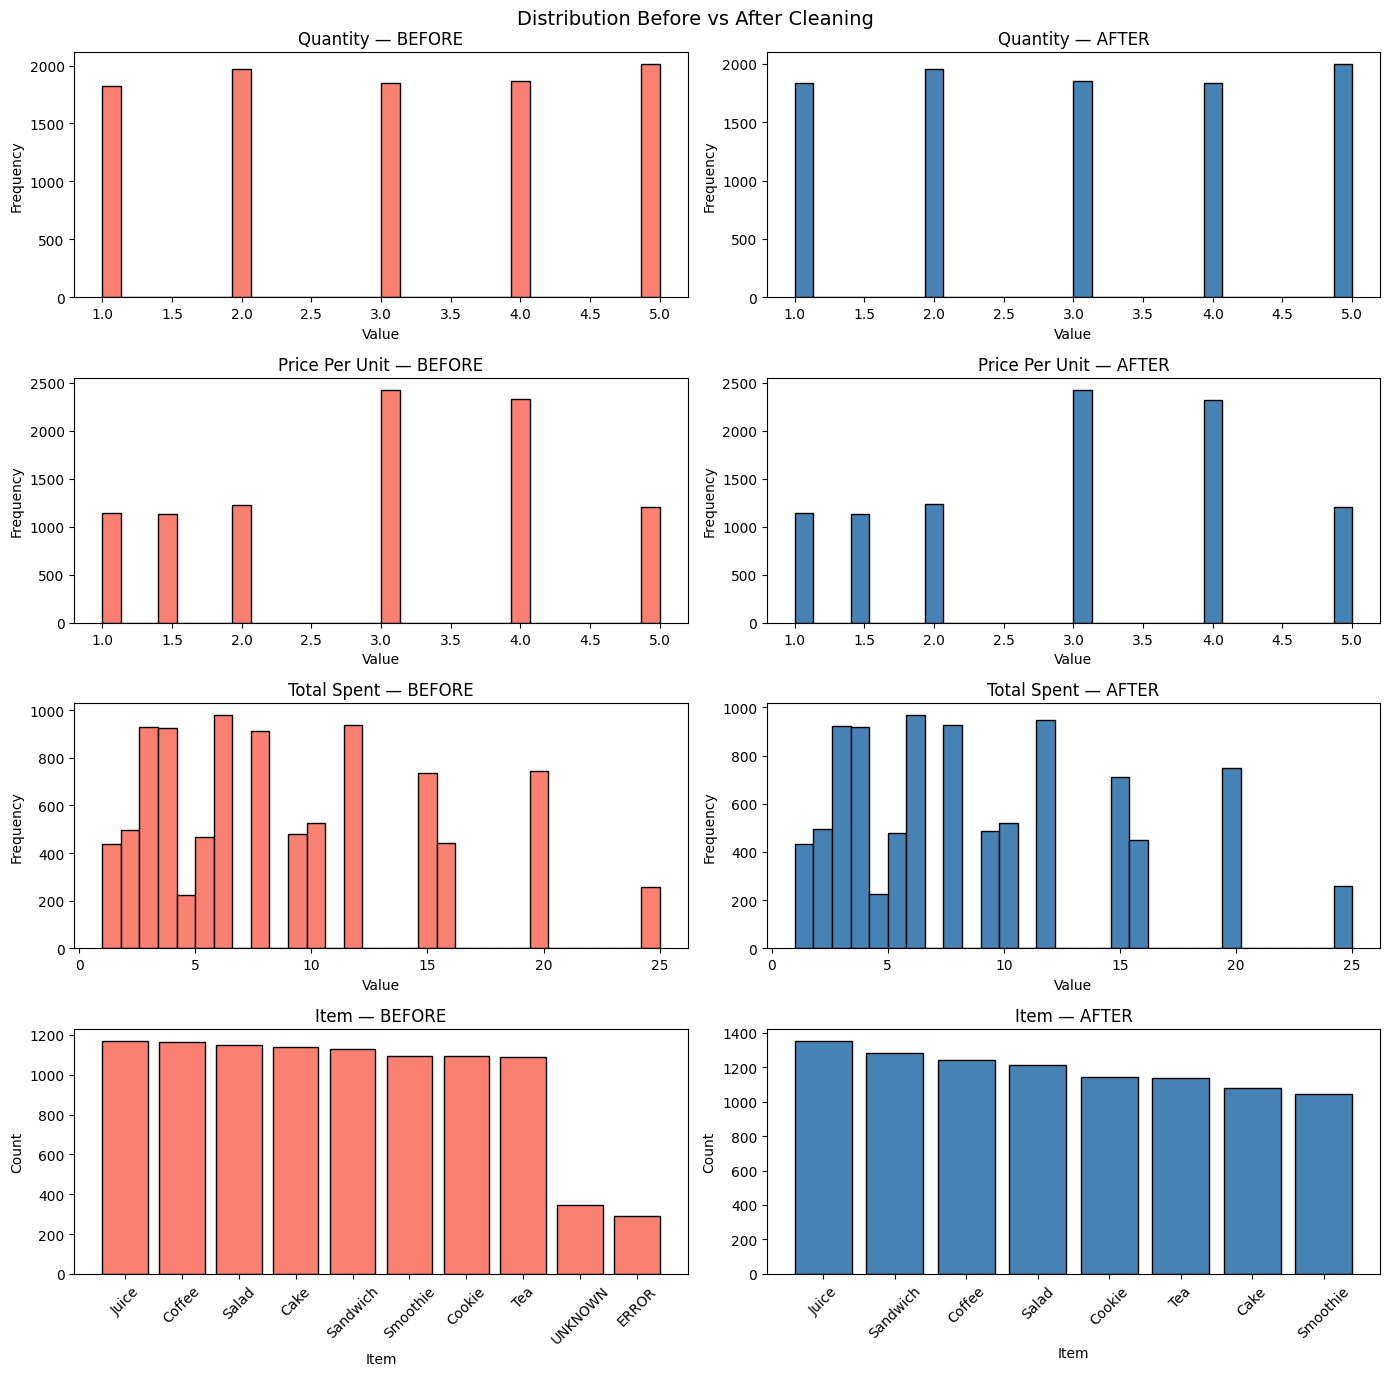

In [87]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(14, 14))

numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']

# Numeric columns - histogram
for i, col in enumerate(numeric_cols):
    before = pd.to_numeric(df[col], errors='coerce').dropna()
    after  = df_clean[col].dropna()

    axes[i, 0].hist(before, bins=30, edgecolor='black', color='salmon')
    axes[i, 0].set_title(f'{col} — BEFORE')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')

    axes[i, 1].hist(after, bins=30, edgecolor='black', color='steelblue')
    axes[i, 1].set_title(f'{col} — AFTER')
    axes[i, 1].set_xlabel('Value')
    axes[i, 1].set_ylabel('Frequency')

# Item column - bar chart
before_item = df['Item'].value_counts(dropna=True)
after_item  = df_clean['Item'].value_counts(dropna=True)

axes[3, 0].bar(before_item.index, before_item.values, color='salmon', edgecolor='black')
axes[3, 0].set_title('Item — BEFORE')
axes[3, 0].set_xlabel('Item')
axes[3, 0].set_ylabel('Count')
axes[3, 0].tick_params(axis='x', rotation=45)

axes[3, 1].bar(after_item.index, after_item.values, color='steelblue', edgecolor='black')
axes[3, 1].set_title('Item — AFTER')
axes[3, 1].set_xlabel('Item')
axes[3, 1].set_ylabel('Count')
axes[3, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Distribution Before vs After Cleaning', fontsize=14)
plt.tight_layout()
plt.savefig('distribution_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

In [88]:
before_pct = df['Item'].value_counts(normalize=True, dropna=True) * 100
after_pct  = df_clean['Item'].value_counts(normalize=True, dropna=True) * 100

comparison = pd.DataFrame({'Before %': before_pct, 'After %': after_pct})
comparison['Diff %'] = (comparison['After %'] - comparison['Before %']).round(2)
print(comparison)

           Before %    After %  Diff %
Item                                  
Cake      11.782352  11.354771   -0.43
Coffee    12.051309  13.062731    1.01
Cookie    11.296162  12.061149    0.76
ERROR      3.020585        NaN     NaN
Juice     12.113375  14.275171    2.16
Salad     11.875453  12.778071    0.90
Sandwich  11.699597  13.516078    1.82
Smoothie  11.337540  10.985767   -0.35
Tea       11.265129  11.966263    0.70
UNKNOWN    3.558498        NaN     NaN
